In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False


try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

print(f"XGBoost available: {XGBOOST_AVAILABLE}")
print(f"Optuna available: {OPTUNA_AVAILABLE}")

Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\Asus\\.matplotlib\\fontlist-v390.json.matplotlib-lock'


XGBoost available: True
Optuna available: True


In [2]:
df = pd.read_csv("../data/cleaned_credit/cleaned_train.csv")
df_test  = pd.read_csv("../data/cleaned_credit/cleaned_test.csv")

cols_to_exclude = ['ID','Customer_ID','Name', 'SSN']
df.drop(columns=cols_to_exclude, inplace=True, errors='ignore')
df_test.drop(columns=cols_to_exclude, inplace=True, errors='ignore')

In [3]:
loan_cols = [
    'Auto Loan', 
    'Credit-Builder Loan', 
    'Debt Consolidation Loan', 
    'Home Equity Loan', 
    'Mortgage Loan', 
    'Not Specified', 
    'Payday Loan', 
    'Personal Loan', 
    'Student Loan', 
    'Unknown Loan'  
]

df[loan_cols] = df[loan_cols].fillna(0)
df_test[loan_cols] = df_test[loan_cols].fillna(0)

df_train, df_val = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Credit_Score'])

In [4]:
##--------------Encoding and Feature Scaling----------------------#

#One hot encoding the features
encode_cols = ['Month', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']
df_train_encoded = pd.get_dummies(df_train, columns=encode_cols, drop_first=True)
df_val_encoded = pd.get_dummies(df_val, columns=encode_cols, drop_first=True)
df_test_encoded = pd.get_dummies(df_test, columns=encode_cols, drop_first=True)

#Input and target seperation
X_train = df_train_encoded.drop(columns=['Credit_Score'])
y_train = df_train_encoded['Credit_Score']

X_val = df_val_encoded.drop(columns=['Credit_Score'])
y_val = df_val_encoded['Credit_Score']

# Align splits
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = df_test_encoded.reindex(columns=X_train.columns, fill_value=0)

# Scale features (StandardScaler fit on train split only)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print(f"Preprocessed Train features shape: {X_train_scaled.shape}")
print(f"Preprocessed Val features shape: {X_val_scaled.shape}")
print(f"Preprocessed Test features shape: {X_test_scaled.shape}")

Preprocessed Train features shape: (80000, 59)
Preprocessed Val features shape: (20000, 59)
Preprocessed Test features shape: (50000, 59)


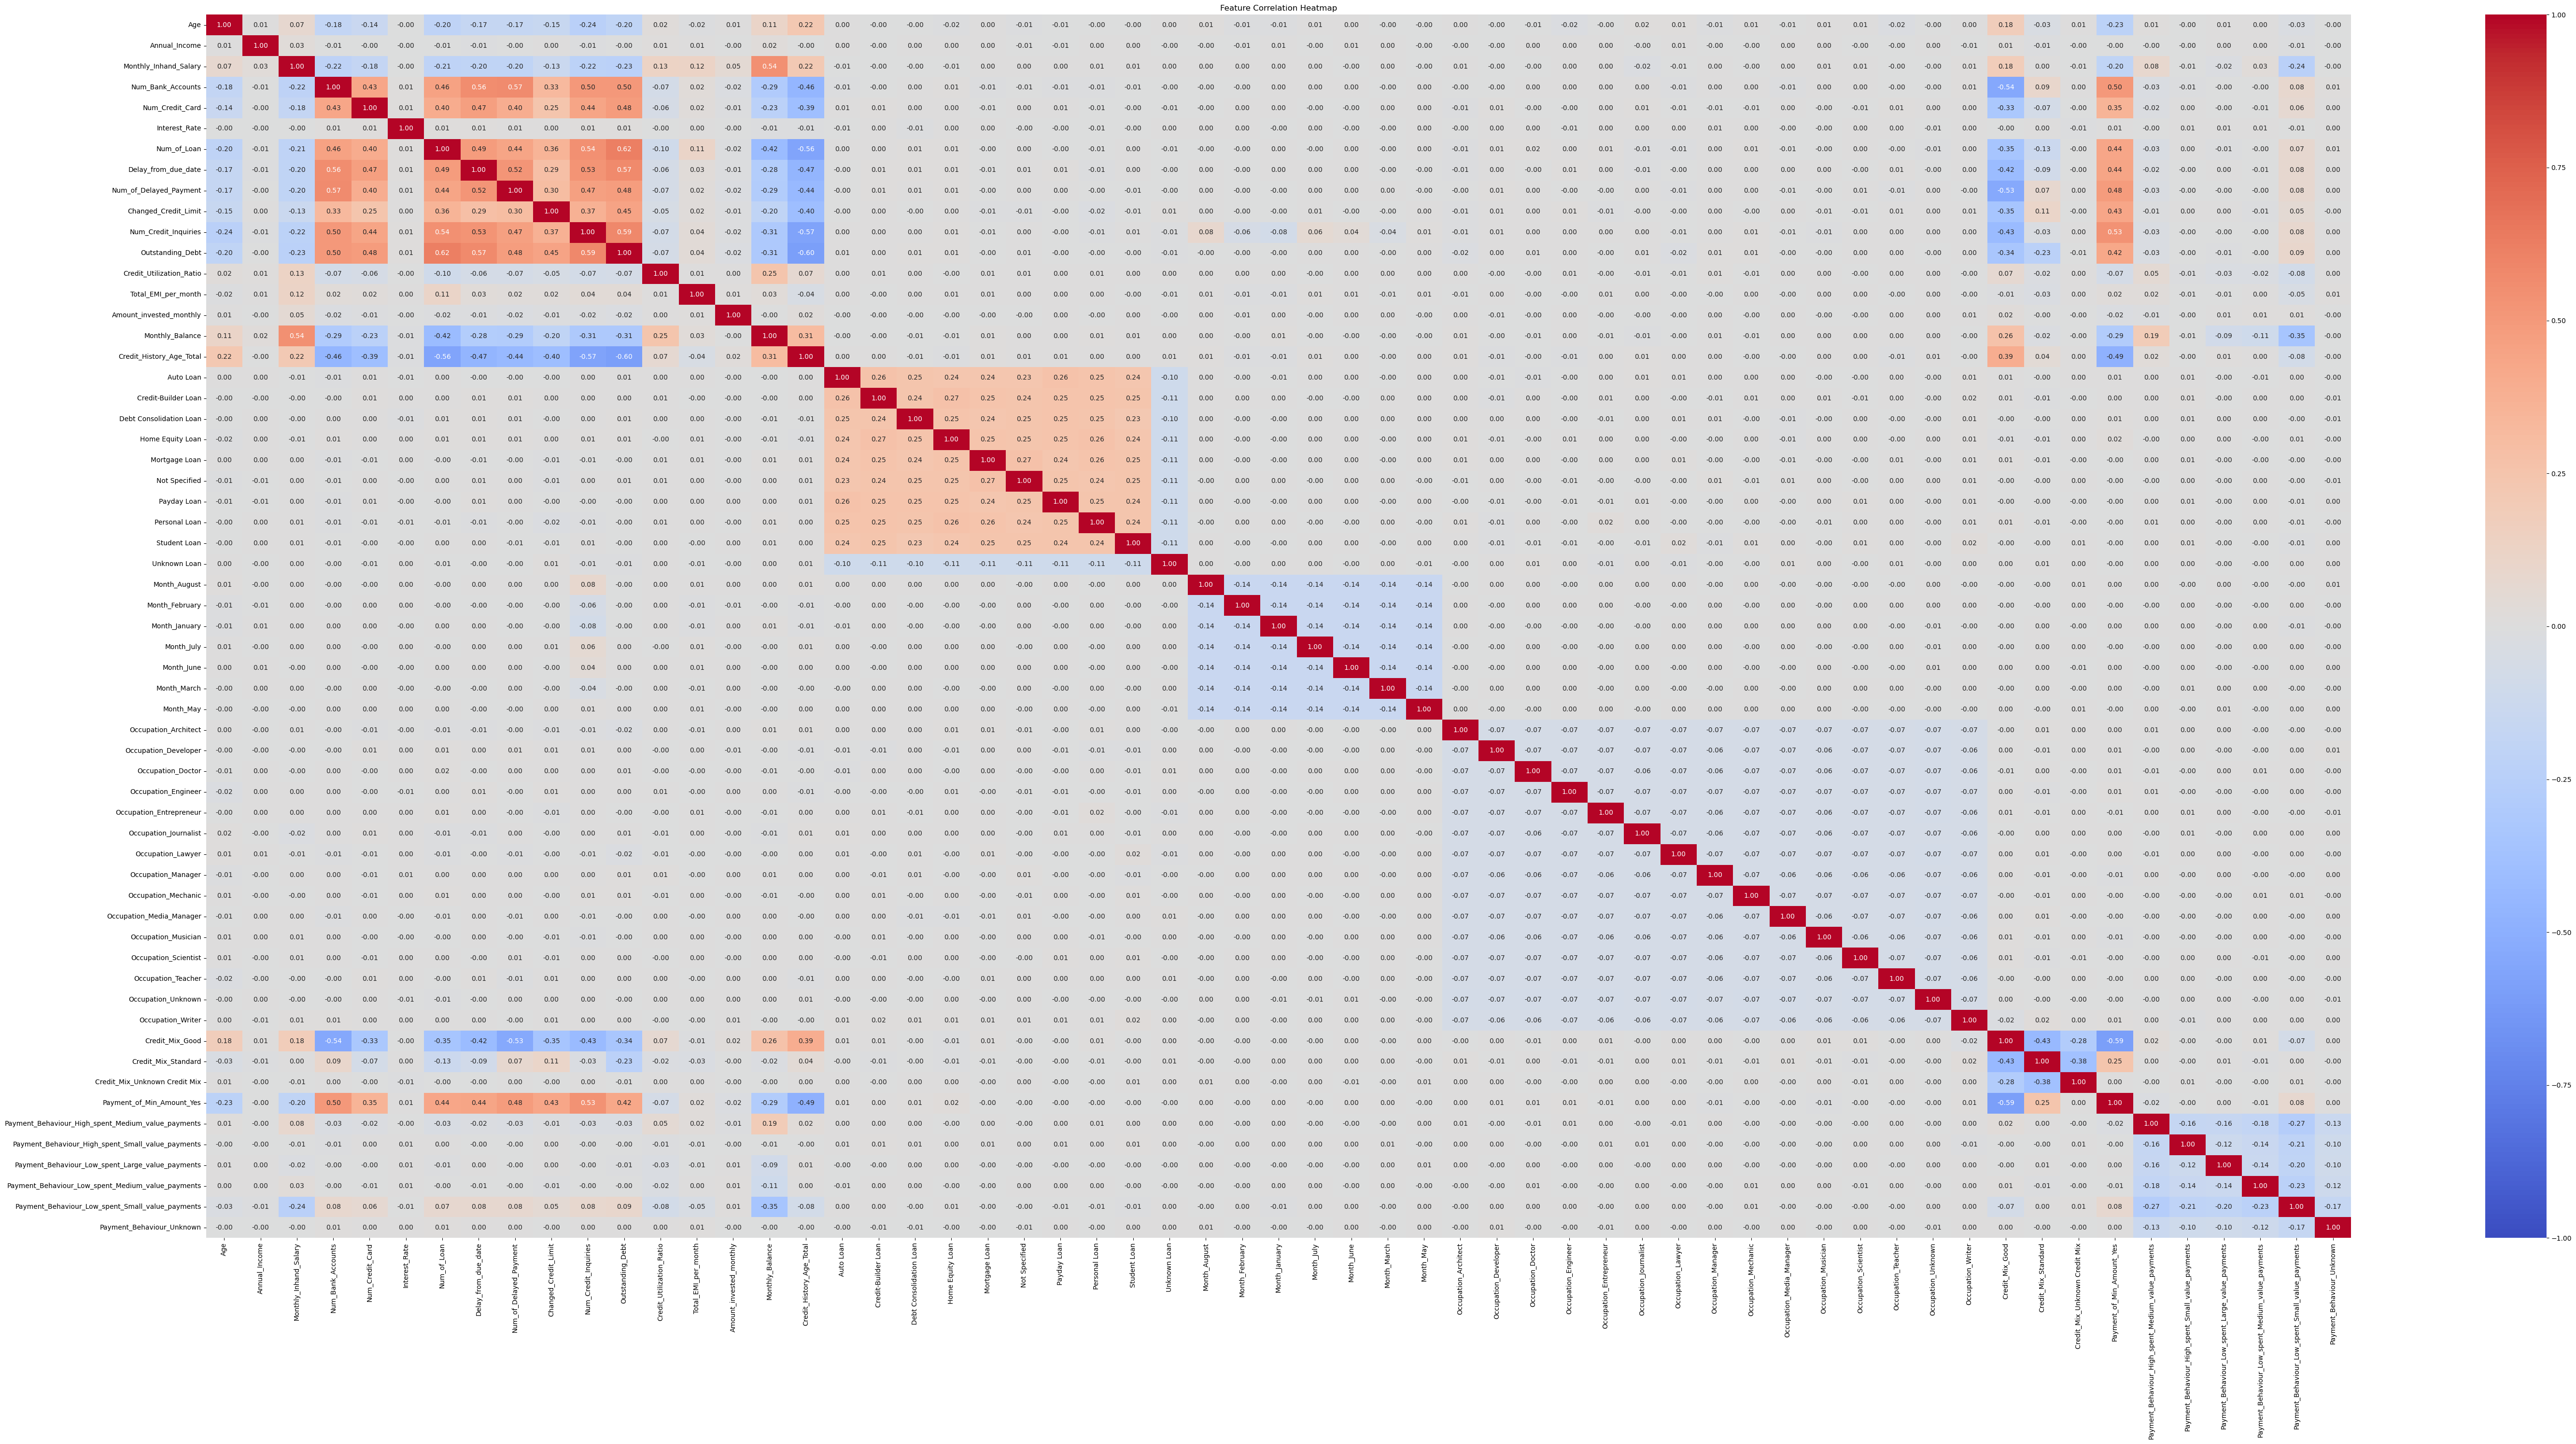

In [5]:
plt.figure(figsize=(60, 30))
sns.heatmap(X_train.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [6]:
threshold = 0.85
target = y_train

corr_matrix = X_train.corr().abs()

# Correlation of features with target
target_corr = X_train.apply(
    lambda col: col.corr(target)
).abs()

drop_cols = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):

        col1 = corr_matrix.columns[i]
        col2 = corr_matrix.columns[j]

        if corr_matrix.iloc[i, j] > threshold:

            if target_corr[col1] < target_corr[col2]:
                drop_cols.add(col1)
            else:
                drop_cols.add(col2)

# Drop highly correlated columns from datasets to avoid multicollinearity
X_train_scaled.drop(columns=drop_cols, inplace=True, errors='ignore')
X_val_scaled.drop(columns=drop_cols, inplace=True, errors='ignore')
X_test_scaled.drop(columns=drop_cols, inplace=True, errors='ignore')

print(f"Dropped {len(drop_cols)} features from training, validation, and test datasets.")
print(f"Remaining features count: {X_train_scaled.shape[1]}")

Dropped 0 features from training, validation, and test datasets.
Remaining features count: 59


In [7]:
# The dataset has already been split, imputed, aligned, and scaled cleanly
# Assign final splits to expected names
X_train = X_train_scaled
X_val = X_val_scaled
X_test = X_val_scaled  # Maps X_val_scaled as holdout test set to maintain downstream references
y_test = y_val

print(f"Train size: {X_train.shape[0]} rows, Validation/Test size: {X_val.shape[0]} rows\n")
print(f"Feature Count: {X_train.shape[1]}")

Train size: 80000 rows, Validation/Test size: 20000 rows

Feature Count: 59


In [8]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=5, random_state=42)
}

if XGBOOST_AVAILABLE:
    models['XG Boost'] = XGBClassifier(n_estimators=300, max_depth=4, random_state=42, eval_metric='logloss')

# Dictionary to store performance metrics
results = []
trained_models = {}

# Train and Evaluate Models
for name, model in models.items():
    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:,1]
    
    # Calculate metrics
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_prob)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': auc
    })
    trained_models[name] = model

# Convert results list to DataFrame
results_df = pd.DataFrame(results)

In [9]:
display(results_df.sort_values(by='Accuracy', ascending=False))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,XG Boost,0.85095,0.761260,0.708103,0.733720,0.906038
1,Random Forest,0.79580,0.639785,0.677069,0.657899,0.836861
0,Logistic Regression,0.77455,0.651561,0.478448,0.551745,0.798820


In [10]:
best_model_name = results_df.sort_values('F1-Score', ascending=False).iloc[0]['Model']
print('Best Model:', best_model_name)
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_val)
y_prob_best = best_model.predict_proba(X_val)[:, 1]

print(f"Classification Report for {best_model_name}:\n")
print(classification_report(y_val, y_pred_best, target_names=['Normal (0)', 'High Risk (1)']))

Best Model: XG Boost
Classification Report for XG Boost:

               precision    recall  f1-score   support

   Normal (0)       0.88      0.91      0.90     14200
High Risk (1)       0.76      0.71      0.73      5800

     accuracy                           0.85     20000
    macro avg       0.82      0.81      0.82     20000
 weighted avg       0.85      0.85      0.85     20000



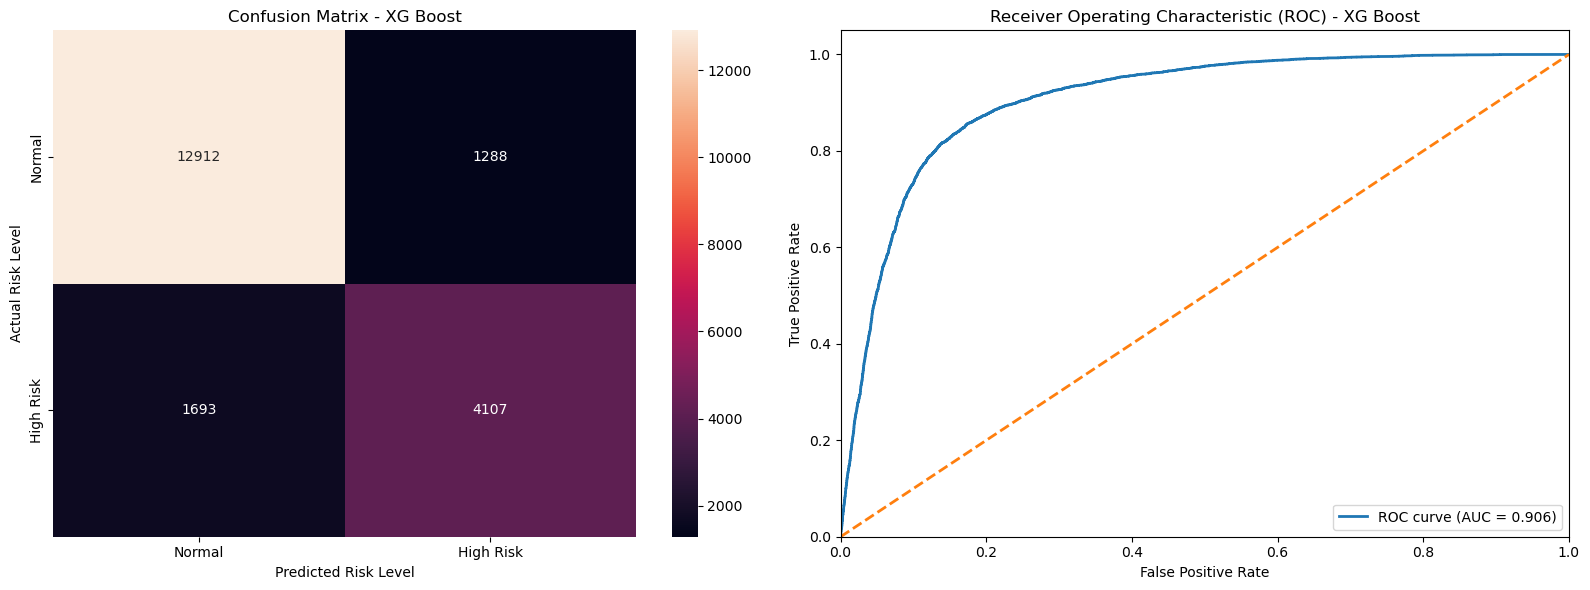

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Confusion Matrix
cm = confusion_matrix(y_val, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='rocket', 
            xticklabels=['Normal', 'High Risk'], 
            yticklabels=['Normal', 'High Risk'], ax=ax1)
ax1.set_title(f'Confusion Matrix - {best_model_name}')
ax1.set_ylabel('Actual Risk Level')
ax1.set_xlabel('Predicted Risk Level')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_prob_best)
best_auc = results_df.loc[results_df["Model"] == best_model_name, "ROC-AUC"].values[0]
ax2.plot(fpr, tpr, lw=2, label=f'ROC curve (AUC = {best_auc:.3f})')
ax2.plot([0, 1], [0, 1], lw=2, linestyle='--')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title(f'Receiver Operating Characteristic (ROC) - {best_model_name}')
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()


In [12]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800, step=100),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 5.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.001, 2.0, log=True),
        'eval_metric': 'logloss',
        'random_state': 42,
        'n_jobs': -1,
    }
    model = XGBClassifier(**params)
    score = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1).mean()
    print(f"  Trial {trial.number:>3}: F1 = {score:.4f}  | params = {params}")
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=False)

print(f"Best F1 (CV): {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

# Train final XGBoost model on the best params found
best_xgb_params = study.best_params.copy()
best_xgb_params.update({'eval_metric': 'logloss', 'random_state': 42, 'n_jobs': -1})
best_model = XGBClassifier(**best_xgb_params)
best_model.fit(X_train, y_train)

# Evaluate
y_pred = best_model.predict(X_val)
y_prob = best_model.predict_proba(X_val)[:, 1]

results.append({
    'Model': 'XG Boost (tuned)',
    'Accuracy': accuracy_score(y_val, y_pred),
    'Precision': precision_score(y_val, y_pred),
    'Recall': recall_score(y_val, y_pred),
    'F1-Score': f1_score(y_val, y_pred),
    'ROC-AUC': roc_auc_score(y_val, y_prob)
})
trained_models['XG Boost (tuned)'] = best_model

results_df = pd.DataFrame(results)
results_df.sort_values('F1-Score', ascending=False)

  Trial   0: F1 = 0.6915  | params = {'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.019129689296217646, 'subsample': 0.7122431226692643, 'colsample_bytree': 0.6451295988585033, 'min_child_weight': 6, 'reg_lambda': 0.3066573334793456, 'reg_alpha': 0.003404729784145532, 'eval_metric': 'logloss', 'random_state': 42, 'n_jobs': -1}
  Trial   1: F1 = 0.7314  | params = {'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.08063912163930305, 'subsample': 0.7568506341571785, 'colsample_bytree': 0.8706684066305346, 'min_child_weight': 4, 'reg_lambda': 0.47751594380228124, 'reg_alpha': 0.053576601335373494, 'eval_metric': 'logloss', 'random_state': 42, 'n_jobs': -1}
  Trial   2: F1 = 0.6851  | params = {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05887678981488051, 'subsample': 0.8334376466584875, 'colsample_bytree': 0.7452280715964144, 'min_child_weight': 5, 'reg_lambda': 0.28529212907535695, 'reg_alpha': 0.001267627937830221, 'eval_metric': 'logloss', 'random_state': 4

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
3,XG Boost (tuned),0.87895,0.798762,0.778793,0.788651,0.934704
2,XG Boost,0.85095,0.761260,0.708103,0.733720,0.906038
1,Random Forest,0.79580,0.639785,0.677069,0.657899,0.836861
0,Logistic Regression,0.77455,0.651561,0.478448,0.551745,0.798820


In [13]:
import optuna
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 5.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.001, 2.0, log=True),
        'n_estimators': 2000,           # upper cap; early stopping finds the real optimum
        'early_stopping_rounds': 50,
        'eval_metric': 'logloss',
        'random_state': 42,
        'n_jobs': -1,
    }

    model = XGBClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    y_pred = model.predict(X_val)
    score = f1_score(y_val, y_pred)

    print(f"  Trial {trial.number:>3}: F1 = {score:.4f}  | best_iteration = {model.best_iteration}  | params = {params}")
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=False)

print(f"Best F1 (CV): {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

# Train final XGBoost model on the best params found, again using early stopping
best_xgb_params = study.best_params.copy()
best_xgb_params.update({
    'n_estimators': 2000,
    'early_stopping_rounds': 50,
    'eval_metric': 'logloss',
    'random_state': 42,
    'n_jobs': -1,
})

best_model = XGBClassifier(**best_xgb_params)
best_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f"Final model stopped at iteration: {best_model.best_iteration}")

# Evaluate
y_pred = best_model.predict(X_val)
y_prob = best_model.predict_proba(X_val)[:, 1]

results.append({
    'Model': 'XG Boost (tuned + early stopping)',
    'Accuracy': accuracy_score(y_val, y_pred),
    'Precision': precision_score(y_val, y_pred),
    'Recall': recall_score(y_val, y_pred),
    'F1-Score': f1_score(y_val, y_pred),
    'ROC-AUC': roc_auc_score(y_val, y_prob)
})
trained_models['XG Boost (tuned + early stopping)'] = best_model

results_df = pd.DataFrame(results)
results_df.sort_values('F1-Score', ascending=False)

  Trial   0: F1 = 0.7720  | best_iteration = 434  | params = {'max_depth': 7, 'learning_rate': 0.19524317232239827, 'subsample': 0.6427438031996481, 'colsample_bytree': 0.6588916856482908, 'min_child_weight': 2, 'reg_lambda': 1.4761063174663853, 'reg_alpha': 0.00418611228281985, 'n_estimators': 2000, 'early_stopping_rounds': 50, 'eval_metric': 'logloss', 'random_state': 42, 'n_jobs': -1}
  Trial   1: F1 = 0.7400  | best_iteration = 1999  | params = {'max_depth': 3, 'learning_rate': 0.1610859224592282, 'subsample': 0.6082547161366186, 'colsample_bytree': 0.8969357699429903, 'min_child_weight': 1, 'reg_lambda': 0.44522109282569466, 'reg_alpha': 0.24986494214368535, 'n_estimators': 2000, 'early_stopping_rounds': 50, 'eval_metric': 'logloss', 'random_state': 42, 'n_jobs': -1}
  Trial   2: F1 = 0.7710  | best_iteration = 1999  | params = {'max_depth': 5, 'learning_rate': 0.07516225514018186, 'subsample': 0.9290754451014254, 'colsample_bytree': 0.7007964637730546, 'min_child_weight': 4, 'reg

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
4,XG Boost (tuned + early stopping),0.88110,0.800915,0.785172,0.792965,0.937353
3,XG Boost (tuned),0.87895,0.798762,0.778793,0.788651,0.934704
2,XG Boost,0.85095,0.761260,0.708103,0.733720,0.906038
1,Random Forest,0.79580,0.639785,0.677069,0.657899,0.836861
0,Logistic Regression,0.77455,0.651561,0.478448,0.551745,0.798820


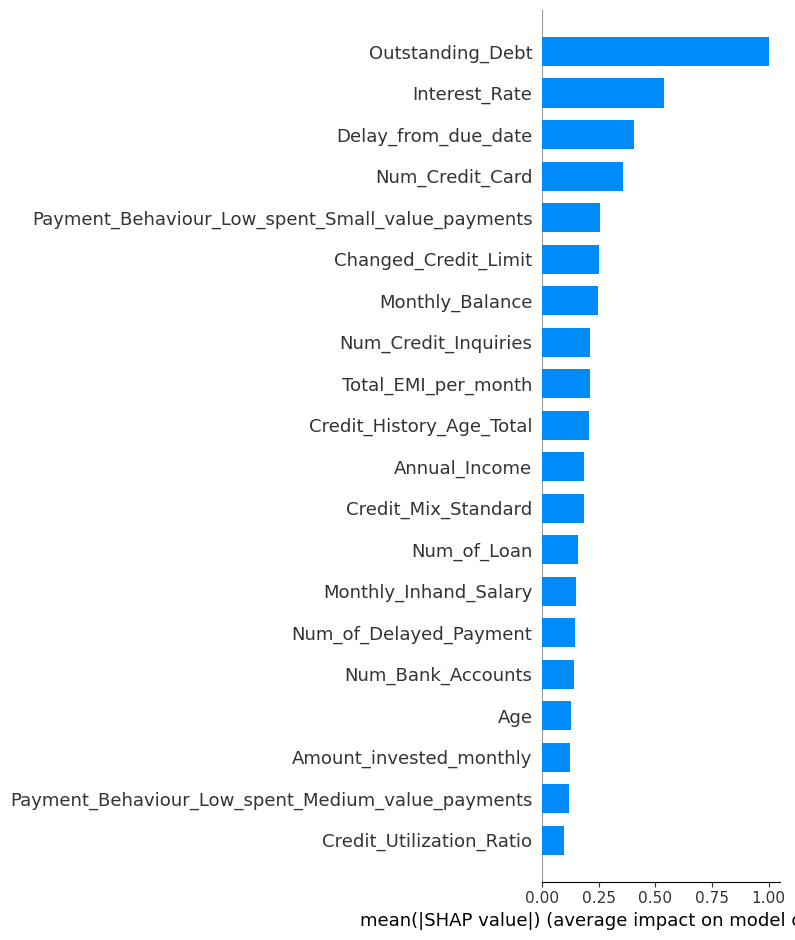

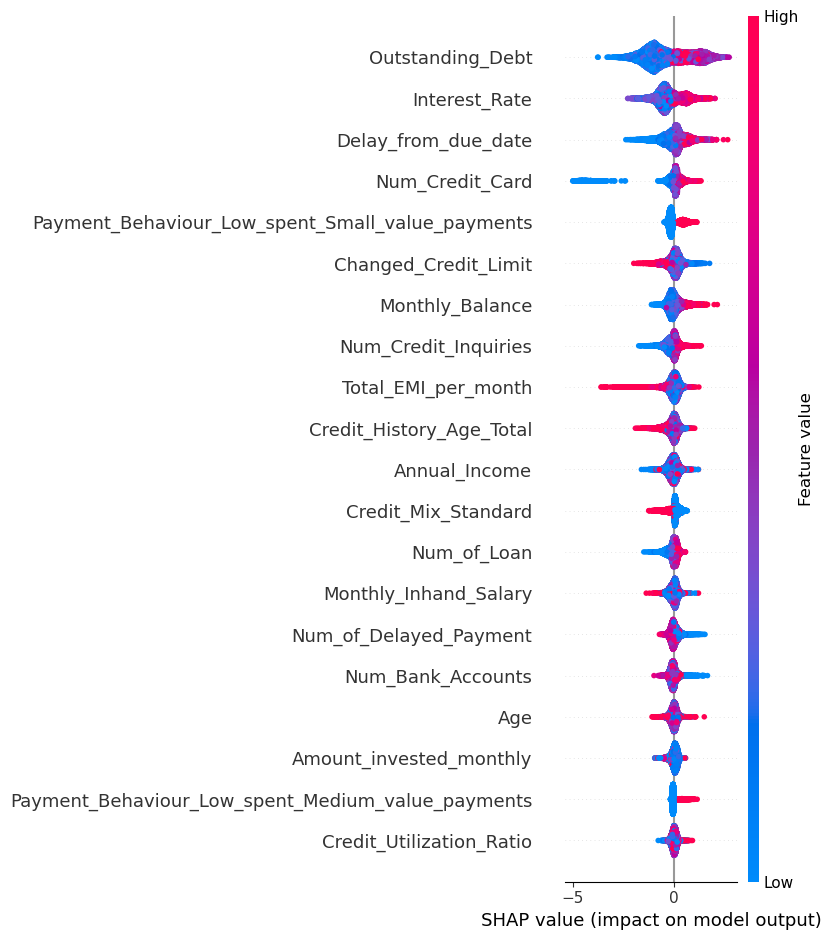

,feature,mean_abs_shap
11,Outstanding_Debt,1.000035
5,Interest_Rate,0.538719
7,Delay_from_due_date,0.406408
4,Num_Credit_Card,0.357673
57,Payment_Behaviour_Low_spent_Small_value_payments,0.254024
9,Changed_Credit_Limit,0.251158
15,Monthly_Balance,0.246569
10,Num_Credit_Inquiries,0.213625
13,Total_EMI_per_month,0.209827
16,Credit_History_Age_Total,0.208246


In [14]:
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_val)

# Summary bar chart — overall feature importance
shap.summary_plot(shap_values, X_val, plot_type="bar")

# Beeswarm — shows direction + magnitude per feature
shap.summary_plot(shap_values, X_val)

# Ranked table
shap_importance = pd.DataFrame({
    'feature': X_val.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

shap_importance.head(15)

In [15]:
import numpy as np
from sklearn.metrics import f1_score

y_prob = best_model.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = [f1_score(y_val, (y_prob >= t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]

print(f"Best threshold: {best_threshold:.2f}, F1: {max(f1_scores):.4f}")

Best threshold: 0.30, F1: 0.8172


In [16]:
import os
import numpy as np
import joblib
from sklearn.metrics import f1_score

# Create the output folder
output_dir = 'artifacts'
os.makedirs(output_dir, exist_ok=True)

# Save everything into the folder
joblib.dump(best_model, os.path.join(output_dir, 'xgboost_credit_model.joblib'))
joblib.dump(scaler, os.path.join(output_dir, 'scaler.joblib'))
joblib.dump(list(X_train.columns), os.path.join(output_dir, 'feature_columns.joblib'))
joblib.dump(best_threshold, os.path.join(output_dir, 'best_threshold.joblib'))

print(f"Model artifacts saved to '{output_dir}/'")

Model artifacts saved to 'artifacts/'
